In [3]:
import pandas as pd
import numpy as np

df = pd.read_parquet('../data/processed/pfas_acs_zcta_month.parquet')

In [4]:
contain_pfas = df[df['any_detection']== True]
contain_pfas_by_zcta = contain_pfas.groupby('zcta')[['mean_result_ngL']].mean().sort_values(by='mean_result_ngL', ascending=False)
contain_pfas_by_zcta

,mean_result_ngL
zcta,
55071,1225.000000
44118,400.000000
55128,285.990556
96950,257.999126
85258,171.150000
...,...
21213,3.000000
30917,3.000000
86404,3.000000


In [5]:
max(df["n_contaminants"]) #only search for a maximum of 29 PFAS chemicals though there
#are estimates of 10,000 to 15,000 PFAS chemicals

29

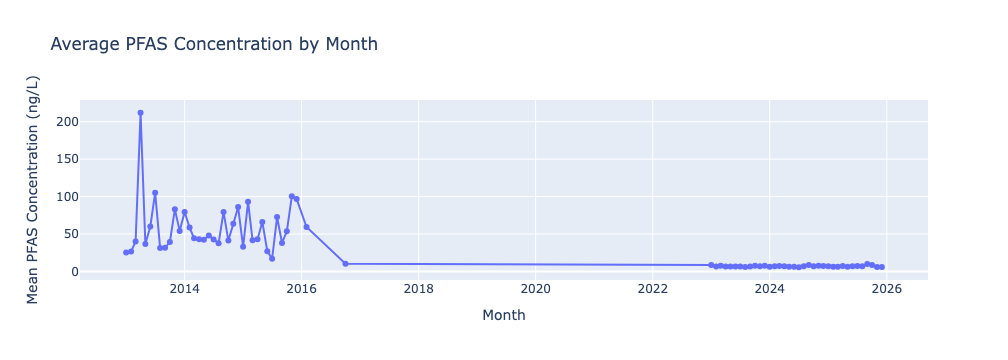

In [6]:
import plotly.express as px

contain_pfas_grouped = (
    contain_pfas
    .groupby("month")["mean_result_ngL"]
    .mean()
    .reset_index()
)

fig = px.line(
    contain_pfas_grouped,
    x="month",
    y="mean_result_ngL",
    markers=True,
    title="Average PFAS Concentration by Month"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Mean PFAS Concentration (ng/L)"
)

fig.show()

In [7]:
contain_pfas_grouped_all = contain_pfas.groupby('zcta').agg({"n_records": "sum", 
                                  "mean_result_ngL": "mean", 
                                  "n_detections": "sum",
                                  "pct_below_poverty": "mean",
                                  "pct_white_nh": "mean",
                                  "pct_black_nh": "mean", 
                                  "pct_asian_nh": "mean",
                                  "pct_amerind_nh": "mean",
                                  "pct_hispanic": "mean",
                                  "pct_nonwhite": "mean", 
                                  "pct_renter": "mean"}).sort_values(by="mean_result_ngL", ascending=False)
contain_pfas_grouped_all

,n_records,mean_result_ngL,n_detections,pct_below_poverty,pct_white_nh,pct_black_nh,pct_asian_nh,pct_amerind_nh,pct_hispanic,pct_nonwhite,pct_renter
zcta,,,,,,,,,,,
55071,58,1225.000000,2,5.270410,77.509902,2.548648,5.579473,0.000000,11.520579,22.490098,20.428266
44118,6,400.000000,1,15.683206,57.107133,33.392755,3.117185,0.079229,2.059967,42.892867,38.783410
55128,280,285.990556,26,6.249566,66.619451,8.319226,12.855415,0.310935,6.128865,33.380549,22.017729
96950,1053,257.999126,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
85258,41,171.150000,9,10.801147,84.622316,2.691584,3.667137,0.082276,6.170663,15.377684,26.246288
...,...,...,...,...,...,...,...,...,...,...,...
21213,87,3.000000,1,24.581831,5.939529,86.273807,0.218787,0.272587,4.472580,94.060471,46.821759
30917,58,3.000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
86404,29,3.000000,1,13.284741,82.561221,0.174918,0.800382,0.376338,12.482773,17.438779,17.568328
